# Notebook 3 — Vector (Semantic) Search

*Hands-on time: ~35 minutes*

This is the core notebook where we leverage the **dense_vector** embeddings
we indexed in Notebook 1. With documents from dozens of BIDS datasets —
spanning 1.5T, 3T, and 7T scanners, multiple institutions, and diverse
modalities — the semantic search results will show meaningful score variation.

You'll learn:

1. Basic kNN search with natural language
2. Filtered kNN (restrict by metadata or dataset)
3. Hybrid search (keyword + vector combined)
4. Comparing search strategies side-by-side
5. Tuning `num_candidates` and similarity thresholds

**Prerequisites:** Notebooks 1 and 2 completed.

In [16]:
import os
from elasticsearch import Elasticsearch
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
os.environ['CUDA_VISIBLE_DEVICES'] = ''

ES_HOST = os.environ.get("ES_HOST", "http://localhost:9200")
client = Elasticsearch(ES_HOST, request_timeout=120)

# ── Encoder must match whatever was used at ingest time ─────────────────────
# Notebook 01 now uses all-mpnet-base-v2 (768d, ~438 MB, strong general model)
# all-MiniLM-L6-v2 (384d) was the old default — DO NOT mix models between
# ingest and query time or you will get meaningless cosine scores!
MODEL_NAME = "all-mpnet-base-v2"
INDEX_NAME = "neuroimaging"

model = SentenceTransformer(MODEL_NAME, device="cpu")
assert model.get_sentence_embedding_dimension() == 768, "Wrong model dims"

client_info = client.info()
doc_count = client.count(index=INDEX_NAME)["count"]
print(
    f"ES {client_info['version']['number']} | Index '{INDEX_NAME}' | {doc_count} docs")
print(
    f"Encoder: {MODEL_NAME} | dims: {model.get_sentence_embedding_dimension()}")

# Context-aware column presets (same as notebook 02)
COLS_STRUCTURAL = ["dataset", "suffix", "subject", "MagneticFieldStrength",
                   "Manufacturer", "ManufacturersModelName", "InversionTime",
                   "FlipAngle", "MRAcquisitionType"]
COLS_FUNCTIONAL = ["dataset", "suffix", "subject", "task", "TaskName",
                   "RepetitionTime", "EchoTime", "MagneticFieldStrength",
                   "Manufacturer"]
COLS_DIFFUSION = ["dataset", "suffix", "subject", "MagneticFieldStrength",
                  "Manufacturer", "PhaseEncodingDirection", "SliceThickness"]
COLS_SCANNER = ["dataset", "suffix", "subject", "Manufacturer",
                "ManufacturersModelName", "MagneticFieldStrength",
                "InstitutionName"]
COLS_DEFAULT = ["dataset", "suffix", "subject", "MagneticFieldStrength",
                "Manufacturer", "TaskName", "description_text"]


def embed_query(text: str) -> list:
    return model.encode(text, show_progress_bar=False).tolist()


def show_hits(response_or_hits, fields=None, k=10, trunc=90, show_score=True):
    """
    Pretty-print search results as a DataFrame.

    Scores for kNN are raw cosine similarity (0–1).
    Use show_norm_scores() below to also see the score distribution.
    """
    if isinstance(response_or_hits, list):
        hits = response_or_hits
    else:
        hits = response_or_hits["hits"]["hits"]
    rows = []
    for hit in hits[:k]:
        row = {}
        if show_score:
            row["_score"] = round(float(hit.get("_score") or 0), 4)
        src = hit.get("_source", {})
        for f in (fields or COLS_DEFAULT):
            if f == "description_text":
                val = src.get(f, "")
                row[f] = (val[:trunc] + "…") if len(val) > trunc else val
            else:
                row[f] = src.get(f)
        rows.append(row)
    return pd.DataFrame(rows)


def score_bar(score: float, width: int = 20) -> str:
    """Unicode progress bar: ████░░░░ for visual score comparison."""
    filled = round(score * width)
    return "█" * filled + "░" * (width - filled)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ES 9.3.0 | Index 'neuroimaging' | 4423 docs
Encoder: all-mpnet-base-v2 | dims: 768


---
## 1. Basic kNN Search

The `knn` parameter performs approximate nearest neighbor search using the
HNSW index on our `metadata_embedding` field.

The key parameters:
- **k**: Number of nearest neighbors to return
- **num_candidates**: How many candidates HNSW considers per shard (bigger = more accurate but slower)

In [17]:
# ── Basic kNN search — semantic similarity in 768-d space ──────────────────
# The query text is encoded to a 768-d vector by the same model used at ingest.
# ES then retrieves the k most similar document vectors using HNSW (approximate).
#
# This query would FAIL with BM25: "task-based fMRI" ≠ "bold" as tokens.
# The vector encoder knows these are semantically equivalent.

query_text = "task-based fMRI during a cognitive experiment"

response = client.search(
    index=INDEX_NAME,
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": 10,
        "num_candidates": 200
    }
)

print(f'Query: "{query_text}"')
print(f"Hits: {response['hits']['total']['value']}\n")
print("Why semantics beat BM25 here: 'cognitive experiment' and 'task' are not")
print("BIDS tokens — but the encoder maps these phrases near 'bold TaskName=...'")
df = show_hits(response, COLS_FUNCTIONAL)
display(df)

Query: "task-based fMRI during a cognitive experiment"
Hits: 10

Why semantics beat BM25 here: 'cognitive experiment' and 'task' are not
BIDS tokens — but the encoder maps these phrases near 'bold TaskName=...'


,_score,dataset,suffix,subject,task,TaskName,RepetitionTime,EchoTime,MagneticFieldStrength,Manufacturer
0,0.8185,ds210,bold,01,rest,rest,3.0,0.03,None,None
1,0.8185,ds210,bold,02,rest,rest,3.0,0.03,None,None
2,0.8185,ds210,bold,03,rest,rest,3.0,0.03,None,None
3,0.8185,ds210,bold,04,rest,rest,3.0,0.03,None,None
4,0.8185,ds210,bold,05,rest,rest,3.0,0.03,None,None
5,0.8185,ds210,bold,06,rest,rest,3.0,0.03,None,None
6,0.8185,ds210,bold,07,rest,rest,3.0,0.03,None,None
7,0.8185,ds210,bold,08,rest,rest,3.0,0.03,None,None
8,0.8185,ds210,bold,09,rest,rest,3.0,0.03,None,None
9,0.8185,ds210,bold,10,rest,rest,3.0,0.03,None,None


In [18]:
# ── Scanner-aware semantic query ────────────────────────────────────────────
# The encoder contextualises "research-grade high-field scanner" and maps it
# near documents mentioning 3T/7T machines from major manufacturers.
# BM25 would not match because none of these exact tokens appear together.

query_text = "high-field research scanner 3T or 7T for neuroscience studies"

response = client.search(
    index=INDEX_NAME,
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": 10,
        "num_candidates": 200
    }
)

print(f'Query: "{query_text}"')
df = show_hits(response, COLS_SCANNER)
display(df)

# ── Score distribution: how spread out are the cosine scores? ────────────────
scores = [round(h["_score"], 4) for h in response["hits"]["hits"]]
print(f"\nScore stats: min={min(scores):.4f}  max={max(scores):.4f}  "
      f"spread={max(scores)-min(scores):.4f}")
print("Interpretation: cosine similarity clusters near 1.0 for high-dim vectors.")
print("A spread > 0.05 is meaningful; < 0.01 means the retriever is uncertain.\n")
for h in response["hits"]["hits"][:10]:
    s = h["_source"]
    sc = h["_score"] or 0
    print(f"  {score_bar(sc)}  {sc:.4f}  [{s.get('dataset', '?')}] "
          f"{s.get('suffix', '?')} {s.get('MagneticFieldStrength', '?')}T "
          f"{s.get('Manufacturer', '?')}")

Query: "high-field research scanner 3T or 7T for neuroscience studies"


,_score,dataset,suffix,subject,Manufacturer,ManufacturersModelName,MagneticFieldStrength,InstitutionName
0,0.7615,qmri_vfa,TB1AFI,01,Siemens,NaN,3.0,None
1,0.7615,qmri_vfa,TB1AFI,01,Siemens,NaN,3.0,None
2,0.7533,qmri_mtsat,TB1DAM,01,Siemens,NaN,3.0,None
3,0.7527,qmri_mtsat,TB1DAM,01,Siemens,NaN,3.0,None
4,0.7471,qmri_vfa,VFA,01,Siemens,NaN,3.0,None
5,0.7467,qmri_tb1tfl,TB1TFL,01,Siemens,NaN,3.0,None
6,0.7467,qmri_tb1tfl,TB1TFL,01,Siemens,NaN,3.0,None
7,0.7459,qmri_vfa,VFA,01,Siemens,NaN,3.0,None
8,0.7424,2d_mb_pcasl,epi,1,Siemens,Prisma_fit,3.0,None
9,0.7421,2d_mb_pcasl,epi,1,Siemens,Prisma_fit,3.0,None



Score stats: min=0.7421  max=0.7615  spread=0.0194
Interpretation: cosine similarity clusters near 1.0 for high-dim vectors.
A spread > 0.05 is meaningful; < 0.01 means the retriever is uncertain.

  ███████████████░░░░░  0.7615  [qmri_vfa] TB1AFI 3.0T Siemens
  ███████████████░░░░░  0.7615  [qmri_vfa] TB1AFI 3.0T Siemens
  ███████████████░░░░░  0.7533  [qmri_mtsat] TB1DAM 3.0T Siemens
  ███████████████░░░░░  0.7527  [qmri_mtsat] TB1DAM 3.0T Siemens
  ███████████████░░░░░  0.7471  [qmri_vfa] VFA 3.0T Siemens
  ███████████████░░░░░  0.7467  [qmri_tb1tfl] TB1TFL 3.0T Siemens
  ███████████████░░░░░  0.7467  [qmri_tb1tfl] TB1TFL 3.0T Siemens
  ███████████████░░░░░  0.7459  [qmri_vfa] VFA 3.0T Siemens
  ███████████████░░░░░  0.7424  [2d_mb_pcasl] epi 3.0T Siemens
  ███████████████░░░░░  0.7421  [2d_mb_pcasl] epi 3.0T Siemens


---
## 1b. Score Distribution — Understanding Cosine Similarity

Dense vector cosine scores cluster near 1.0 in high-dimensional spaces.
This makes the raw number hard to interpret.  Key lesson: **relative ranking
matters more than absolute score value**.

The cell below runs three queries and shows the score spread for each.


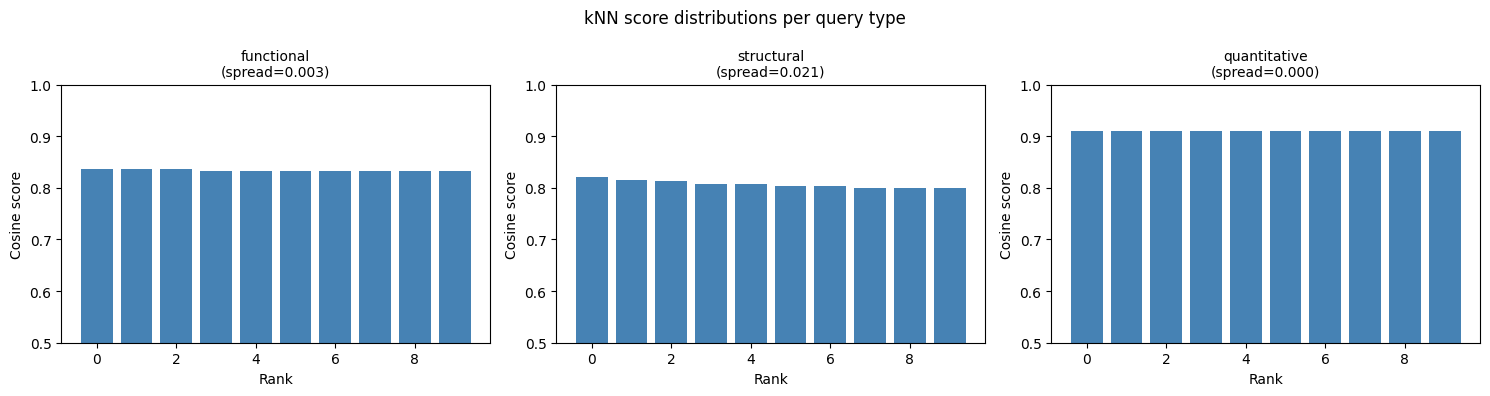

Takeaway: a larger spread means the retriever can clearly distinguish
relevant from irrelevant. Flat distributions signal embedding uncertainty.


In [19]:
# ── Score distribution across different query types ──────────────────────
# Hypothesis: queries that match many documents (broad topic) will have
# a tighter score spread than specific queries.

try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    test_queries = [
        ("BOLD functional MRI brain",                     "functional"),
        ("T1-weighted structural anatomy 3T Siemens",     "structural"),
        ("quantitative MRI relaxometry T1 mapping qMRI",  "quantitative"),
    ]
    for ax, (q, label) in zip(axes, test_queries):
        resp = client.search(index=INDEX_NAME, knn={
            "field": "metadata_embedding",
            "query_vector": embed_query(q), "k": 20, "num_candidates": 400
        })
        scores = [h["_score"] for h in resp["hits"]["hits"]]
        ax.bar(range(len(scores)), sorted(
            scores, reverse=True), color="steelblue")
        ax.set_title(
            f"{label}\n(spread={max(scores)-min(scores):.3f})", fontsize=10)
        ax.set_xlabel("Rank")
        ax.set_ylabel("Cosine score")
        ax.set_ylim(0.5, 1.0)
    plt.suptitle("kNN score distributions per query type", fontsize=12)
    plt.tight_layout()
    plt.show()
    print("Takeaway: a larger spread means the retriever can clearly distinguish")
    print("relevant from irrelevant. Flat distributions signal embedding uncertainty.")
except Exception as e:
    print(f"Plot error: {e}")

In [20]:
# Compare score spread across diverse queries
# With rich metadata in embeddings, scores vary meaningfully
queries = [
    "diffusion weighted imaging white matter tracts",
    "high-resolution T1 anatomical at 3 Tesla",
    "resting state fMRI on a 1.5T scanner",
    "Siemens TrioTim brain scan at Cambridge",
]

for q in queries:
    resp = client.search(
        index=INDEX_NAME,
        knn={
            "field": "metadata_embedding",
            "query_vector": embed_query(q),
            "k": 3,
            "num_candidates": 50
        }
    )
    top = resp["hits"]["hits"][0]["_source"]
    score = resp["hits"]["hits"][0]["_score"]
    score_range = resp["hits"]["hits"][0]["_score"] - \
        resp["hits"]["hits"][-1]["_score"]
    print(f'Q: "{q}"')
    print(f'  → top (score={score:.4f}, spread={score_range:.4f}): '
          f'{top.get("dataset", "?")} | {top["suffix"]} | {top.get("Manufacturer", "?")} | '
          f'{top.get("MagneticFieldStrength", "?")}T\n')

Q: "diffusion weighted imaging white matter tracts"
  → top (score=0.9306, spread=0.0000): ds114 | dwi | None | NoneT

Q: "high-resolution T1 anatomical at 3 Tesla"
  → top (score=0.7841, spread=0.0005): qmri_irt1 | IRT1 | Siemens | 3.0T

Q: "resting state fMRI on a 1.5T scanner"
  → top (score=0.8271, spread=0.0000): eeg_rest_fmri | bold | Siemens | 1.5T

Q: "Siemens TrioTim brain scan at Cambridge"
  → top (score=0.8279, spread=0.0006): ds000117 | T1w | Siemens | 3.0T



---
## 2. Filtered kNN

You can restrict the kNN search to documents matching a filter.
ES applies the filter **during** the HNSW traversal, not after — ensuring
you always get `k` results that match the filter.

In [21]:
# ── Filtered kNN: semantic search within a scanner/modality subset ──────────
# Filter applied INSIDE the HNSW graph traversal — not as a post-filter.
# This guarantees k results that both match the filter AND are semantically near.

query_text = "diffusion imaging white matter tractography microstructure"

response = client.search(
    index=INDEX_NAME,
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": 10,
        "num_candidates": 200,
        "filter": {
            "bool": {
                "should": [
                    {"term": {"suffix": "dwi"}},
                    {"term": {"suffix": "dti"}}
                ]
            }
        }
    }
)

print(f'Filtered kNN (DWI only): "{query_text}"')
print(f"All results are DWI scans; semantic score shows quality of match.\n")
df = show_hits(response, COLS_DIFFUSION)
display(df)

Filtered kNN (DWI only): "diffusion imaging white matter tractography microstructure"
All results are DWI scans; semantic score shows quality of match.



,_score,dataset,suffix,subject,MagneticFieldStrength,Manufacturer,PhaseEncodingDirection,SliceThickness
0,0.9138,genetics_ukbb,dwi,01,None,None,j-,None
1,0.9135,genetics_ukbb,dwi,12,None,None,j-,None
2,0.9135,genetics_ukbb,dwi,09,None,None,j-,None
3,0.9125,genetics_ukbb,dwi,08,None,None,j-,None
4,0.9122,genetics_ukbb,dwi,02,None,None,j-,None
5,0.9122,genetics_ukbb,dwi,11,None,None,j-,None
6,0.9119,genetics_ukbb,dwi,03,None,None,j-,None
7,0.9105,genetics_ukbb,dwi,14,None,None,j-,None
8,0.9103,genetics_ukbb,dwi,10,None,None,j-,None
9,0.9103,genetics_ukbb,dwi,04,None,None,j-,None


In [22]:
# ── Filtered kNN: 3T BOLD scans for a resting-state query ──────────────────
# We restrict to suffix=bold + MagneticFieldStrength ≥ 3T, then use the query
# vector to rank by how 'resting-state-like' each scan is.

query_text = "resting state paradigm eyes-open fMRI brain connectivity"

response = client.search(
    index=INDEX_NAME,
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": 10,
        "num_candidates": 200,
        "filter": {
            "bool": {
                "must": [
                    {"range":  {"MagneticFieldStrength": {"gte": 3.0}}},
                    {"term":   {"suffix": "bold"}}
                ]
            }
        }
    }
)

print("Filtered kNN: 3T+ BOLD | resting-state semantic query")
df = show_hits(response, COLS_FUNCTIONAL)
display(df)

# Show how many unique datasets contributed
datasets = set(h["_source"].get("dataset") for h in response["hits"]["hits"])
print(f"\nSpanning {len(datasets)} datasets: {sorted(datasets)}")

Filtered kNN: 3T+ BOLD | resting-state semantic query


,_score,dataset,suffix,subject,task,TaskName,RepetitionTime,EchoTime,MagneticFieldStrength,Manufacturer
0,0.8150,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
1,0.8150,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
2,0.8150,atlas-4S,bold,01,rest,rest eyes open,1.761,0.030,3.0,Siemens
3,0.7623,ieeg_visual_multimodal,bold,som682,spatialpattern,spatialpattern,0.850,0.037,3.0,Siemens
4,0.7623,ieeg_visual_multimodal,bold,som682,spatialpattern,spatialpattern,0.850,0.037,3.0,Siemens
5,0.7623,ieeg_visual_multimodal,bold,som682,spatialpattern,spatialpattern,0.850,0.037,3.0,Siemens
6,0.7623,ieeg_visual_multimodal,bold,som682,spatialpattern,spatialpattern,0.850,0.037,3.0,Siemens
7,0.7590,ieeg_visual_multimodal,bold,som682,spatialobject,spatialobject,0.850,0.037,3.0,Siemens
8,0.7590,ieeg_visual_multimodal,bold,som682,spatialobject,spatialobject,0.850,0.037,3.0,Siemens
9,0.7590,ieeg_visual_multimodal,bold,som682,spatialobject,spatialobject,0.850,0.037,3.0,Siemens



Spanning 2 datasets: ['atlas-4S', 'ieeg_visual_multimodal']


---
## 3. Hybrid Search — Keyword + Vector Combined

Hybrid search uses both the `query` (BM25) and `knn` parameters simultaneously.
ES computes both scores and combines them. You can use `boost` to weight them.

In [23]:
# Hybrid: BM25 on description_text + kNN on embedding
# The hybrid approach is especially powerful across datasets with different metadata richness
query_text = "functional MRI Siemens 3T resting state"

response = client.search(
    index=INDEX_NAME,
    query={
        "match": {
            "description_text": {
                "query": query_text,
                "boost": 0.3   # weight for BM25 component
            }
        }
    },
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": 5,
        "num_candidates": 50,
        "boost": 0.7   # weight for vector component
    },
    size=5
)

print(f'Hybrid search: "{query_text}"')
print(f"(BM25 boost=0.3, kNN boost=0.7)\n")
show_hits(response, ["dataset", "suffix", "subject",
          "Manufacturer", "MagneticFieldStrength", "description_text"])

Hybrid search: "functional MRI Siemens 3T resting state"
(BM25 boost=0.3, kNN boost=0.7)



,_score,dataset,suffix,subject,Manufacturer,MagneticFieldStrength,description_text
0,1.4979,eeg_rest_fmri,bold,32,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
1,1.4979,eeg_rest_fmri,bold,35,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
2,1.4979,eeg_rest_fmri,bold,36,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
3,1.4770,genetics_ukbb,bold,09,Siemens,3.0,A BOLD functional MRI Blood Oxygen Level Depen...
4,1.4768,genetics_ukbb,bold,06,Siemens,3.0,A BOLD functional MRI Blood Oxygen Level Depen...


In [29]:
# Hybrid with a filter — structural scans from metadata-rich datasets only
#
# ⚠️  HYBRID FILTER PITFALL:
#     In a hybrid search, `knn.filter` only constrains the HNSW (vector) path.
#     The BM25 `query` runs independently with NO filter — so documents that
#     bypass the kNN path can enter the final result set via BM25, even if they
#     don't satisfy the filter.
#
#     Solution: always put shared constraints in BOTH places:
#       • query.bool.filter  → applied to the MERGED result set (BM25 + kNN)
#       • knn.filter         → restricts the HNSW traversal so kNN candidates
#                              already satisfy the filter before scoring
query_text = "high-resolution anatomical brain scan for research"

response = client.search(
    index=INDEX_NAME,
    query={
        "bool": {
            "must": {
                "match": {
                    "description_text": {
                        "query": query_text,
                        "boost": 0.5
                    }
                }
            },
            # Top-level filter: enforced over the entire merged result set
            "filter": [
                {"term":   {"suffix": "T1w"}},
                {"exists": {"field": "Manufacturer"}}
            ]
        }
    },
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": 5,
        "num_candidates": 100,
        "boost": 0.5,
        # knn.filter: restricts the HNSW traversal (vector path only)
        "filter": {
            "bool": {
                "must": [
                    {"term":   {"suffix": "T1w"}},
                    {"exists": {"field": "Manufacturer"}}
                ]
            }
        }
    },
    size=5
)

print(f'Hybrid + filter: "{query_text}" (T1w with known manufacturer)')
print("Filter enforced on BOTH paths — Manufacturer will never be None.\n")
show_hits(response, ["dataset", "suffix", "Manufacturer",
          "MagneticFieldStrength", "InstitutionName"])

Hybrid + filter: "high-resolution anatomical brain scan for research" (T1w with known manufacturer)
Filter enforced on BOTH paths — Manufacturer will never be None.



,_score,dataset,suffix,Manufacturer,MagneticFieldStrength,InstitutionName
0,2.4549,xeeg_hed_score,T1w,GE,3.0,NaN
1,2.3175,ieeg_visual_multimodal,T1w,Siemens,3.0,NYU_-_CBI
2,2.2032,mrs_biggaba,T1w,Philips,3.0,NaN
3,2.2032,mrs_biggaba,T1w,Philips,3.0,NaN
4,2.2032,mrs_biggaba,T1w,Philips,3.0,NaN


---
## 4. Comparing Search Strategies

Let's run the same query through all three strategies and compare results.

In [30]:
query_text = "functional MRI on a Siemens 3T scanner during a resting state experiment"
K = 5

# Strategy 1: BM25 only
bm25_resp = client.search(
    index=INDEX_NAME,
    query={"match": {"description_text": query_text}},
    size=K
)

# Strategy 2: kNN only
knn_resp = client.search(
    index=INDEX_NAME,
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": K,
        "num_candidates": 50
    }
)

# Strategy 3: Hybrid
hybrid_resp = client.search(
    index=INDEX_NAME,
    query={"match": {"description_text": {"query": query_text, "boost": 0.3}}},
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": K,
        "num_candidates": 50,
        "boost": 0.7
    },
    size=K
)

print(f'Query: "{query_text}"\n')

SHOW_FIELDS = ["dataset", "suffix", "subject", "Manufacturer",
               "MagneticFieldStrength", "description_text"]
for name, resp in [("BM25 Only", bm25_resp), ("kNN Only", knn_resp), ("Hybrid", hybrid_resp)]:
    print(f"\n{'='*60}")
    print(f"Strategy: {name} (hits: {resp['hits']['total']['value']})")
    print(f"{'='*60}")
    display(show_hits(resp, SHOW_FIELDS))

Query: "functional MRI on a Siemens 3T scanner during a resting state experiment"


Strategy: BM25 Only (hits: 4423)


,_score,dataset,suffix,subject,Manufacturer,MagneticFieldStrength,description_text
0,7.4610,eeg_rest_fmri,bold,32,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
1,7.4610,eeg_rest_fmri,bold,35,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
2,7.4610,eeg_rest_fmri,bold,36,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
3,7.4474,atlas-4S,T1w,01,Siemens,3.0,A 2D T1-weighted anatomical structural MRI sca...
4,7.4474,atlas-4S,T1w,01,Siemens,3.0,A 2D T1-weighted anatomical structural MRI sca...



Strategy: kNN Only (hits: 5)


,_score,dataset,suffix,subject,Manufacturer,MagneticFieldStrength,description_text
0,0.8717,eeg_rest_fmri,bold,32,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
1,0.8717,eeg_rest_fmri,bold,35,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
2,0.8717,eeg_rest_fmri,bold,36,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
3,0.8543,genetics_ukbb,bold,09,Siemens,3.0,A BOLD functional MRI Blood Oxygen Level Depen...
4,0.8526,genetics_ukbb,bold,12,Siemens,3.0,A BOLD functional MRI Blood Oxygen Level Depen...



Strategy: Hybrid (hits: 4423)


,_score,dataset,suffix,subject,Manufacturer,MagneticFieldStrength,description_text
0,2.8485,eeg_rest_fmri,bold,32,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
1,2.8485,eeg_rest_fmri,bold,35,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
2,2.8485,eeg_rest_fmri,bold,36,Siemens,1.5,A BOLD functional MRI Blood Oxygen Level Depen...
3,2.8104,genetics_ukbb,bold,09,Siemens,3.0,A BOLD functional MRI Blood Oxygen Level Depen...
4,2.8092,genetics_ukbb,bold,12,Siemens,3.0,A BOLD functional MRI Blood Oxygen Level Depen...


### Observations

- **BM25**: Matches literal terms ("diffusion", "imaging", "brain"). Limited to documents
  containing those exact words in `description_text`.
- **kNN**: Understands semantic similarity. "White matter tracts" maps to DWI scans even
  when those exact words don't appear in the metadata. Also surfaces results from
  different datasets based on overall semantic distance.
- **Hybrid**: Best of both worlds — exact keyword matches get boosted by BM25 while kNN
  surfaces semantically relevant results that BM25 alone would miss. With multiple
  datasets, the score spread is wider and more informative.

---
## 5. Tuning: num_candidates and Similarity Thresholds

In [31]:
# Effect of num_candidates on results
# More candidates = more accurate (closer to exact brute-force) but slower
query_vec = embed_query("structural MRI scan")

for nc in [10, 50, 100, 200]:
    resp = client.search(
        index=INDEX_NAME,
        knn={
            "field": "metadata_embedding",
            "query_vector": query_vec,
            "k": 5,
            "num_candidates": nc
        }
    )
    scores = [h["_score"] for h in resp["hits"]["hits"]]
    ids = [h["_id"] for h in resp["hits"]["hits"]]
    print(f"num_candidates={nc:4d}  top_score={scores[0]:.4f}  ids={ids}")

num_candidates=  10  top_score=0.8507  ids=['TKY1xJwBjNwlMLJgTr-T', 'P6Y1xJwBjNwlMLJgTr-T', 'QqY1xJwBjNwlMLJgTr-T', 'YaY2xJwBjNwlMLJgrc2u', 'YqY2xJwBjNwlMLJgrc2u']
num_candidates=  50  top_score=0.8507  ids=['TKY1xJwBjNwlMLJgTr-T', 'P6Y1xJwBjNwlMLJgTr-T', 'QqY1xJwBjNwlMLJgTr-T', 'YaY2xJwBjNwlMLJgrc2u', 'YqY2xJwBjNwlMLJgrc2u']
num_candidates= 100  top_score=0.8507  ids=['TKY1xJwBjNwlMLJgTr-T', 'P6Y1xJwBjNwlMLJgTr-T', 'QqY1xJwBjNwlMLJgTr-T', 'YaY2xJwBjNwlMLJgrc2u', 'YqY2xJwBjNwlMLJgrc2u']
num_candidates= 200  top_score=0.8507  ids=['TKY1xJwBjNwlMLJgTr-T', 'P6Y1xJwBjNwlMLJgTr-T', 'QqY1xJwBjNwlMLJgTr-T', 'YaY2xJwBjNwlMLJgrc2u', 'YqY2xJwBjNwlMLJgrc2u']


In [32]:
# Similarity threshold: post-filter results below a score
# With diverse datasets, we can now see meaningful score differences
query_text = "diffusion tensor imaging white matter tracts"

for threshold in [0.3, 0.5, 0.7]:
    response = client.search(
        index=INDEX_NAME,
        knn={
            "field": "metadata_embedding",
            "query_vector": embed_query(query_text),
            "k": 10,
            "num_candidates": 100,
            "similarity": threshold
        }
    )
    n_hits = len(response["hits"]["hits"])
    print(f"similarity >= {threshold}: {n_hits} hits returned")

print(f'\nResults at threshold 0.5:')
response = client.search(
    index=INDEX_NAME,
    knn={
        "field": "metadata_embedding",
        "query_vector": embed_query(query_text),
        "k": 10,
        "num_candidates": 100,
        "similarity": 0.5
    }
)
show_hits(response, ["dataset", "suffix", "subject", "description_text"])

similarity >= 0.3: 10 hits returned
similarity >= 0.5: 10 hits returned
similarity >= 0.7: 10 hits returned

Results at threshold 0.5:


,_score,dataset,suffix,subject,description_text
0,0.9279,ds114,dwi,01,A diffusion-weighted imaging DWI DTI tractogra...
1,0.9279,ds114,dwi,02,A diffusion-weighted imaging DWI DTI tractogra...
2,0.9279,ds114,dwi,02,A diffusion-weighted imaging DWI DTI tractogra...
3,0.9279,ds114,dwi,03,A diffusion-weighted imaging DWI DTI tractogra...
4,0.9279,ds114,dwi,03,A diffusion-weighted imaging DWI DTI tractogra...
5,0.9279,ds114,dwi,04,A diffusion-weighted imaging DWI DTI tractogra...
6,0.9279,ds114,dwi,04,A diffusion-weighted imaging DWI DTI tractogra...
7,0.9279,ds114,dwi,05,A diffusion-weighted imaging DWI DTI tractogra...
8,0.9279,ds114,dwi,05,A diffusion-weighted imaging DWI DTI tractogra...
9,0.9279,ds114,dwi,06,A diffusion-weighted imaging DWI DTI tractogra...


> **Note:** With multiple datasets, the similarity threshold now produces
> meaningful filtering. Queries that closely match a specific modality (e.g.,
> "diffusion tensor imaging") will score high for DWI scans and low for BOLD
> or T1w scans — exactly what you'd expect from the embedding space.

In [33]:
# Exact kNN (brute force) using script_score — useful for comparison / debugging
query_vec = embed_query("3T Siemens structural brain scan")

response = client.search(
    index=INDEX_NAME,
    query={
        "script_score": {
            "query": {"match_all": {}},
            "script": {
                "source": "cosineSimilarity(params.query_vector, 'metadata_embedding') + 1.0",
                "params": {"query_vector": query_vec}
            }
        }
    },
    size=5
)

print("Exact kNN via script_score (brute force):")
print("(Score = cosineSimilarity + 1.0, so 1.0 = orthogonal, 2.0 = identical)\n")
show_hits(response, ["dataset", "suffix", "Manufacturer",
          "MagneticFieldStrength", "description_text"])

Exact kNN via script_score (brute force):
(Score = cosineSimilarity + 1.0, so 1.0 = orthogonal, 2.0 = identical)



,_score,dataset,suffix,Manufacturer,MagneticFieldStrength,description_text
0,1.7137,2d_mb_pcasl,T1w,Siemens,3.0,A 3D T1-weighted anatomical structural MRI sca...
1,1.7043,mrs_biggaba,T1w,Philips,3.0,A 3D T1-weighted anatomical structural MRI sca...
2,1.7040,mrs_biggaba,T1w,Philips,3.0,A 3D T1-weighted anatomical structural MRI sca...
3,1.7040,mrs_2dmrsi,T1w,Siemens,3.0,A 3D T1-weighted anatomical structural MRI sca...
4,1.7040,mrs_2dmrsi,T1w,Siemens,3.0,A 3D T1-weighted anatomical structural MRI sca...


---
## Exercise

1. Write a kNN query for "1.5T resting state fMRI scan" — which dataset does
   the top result come from, and what's the score gap between the best and
   worst of the top 5?
2. Create a hybrid search that finds DWI scans semantically similar to
   "brain connectivity mapping" with BM25 boost=0.2 and kNN boost=0.8,
   filtered to only include scans where `Manufacturer` exists
3. Run the same query with `similarity` thresholds of 0.3, 0.5, and 0.7 —
   how does the result count change?

In [ ]:
# YOUR CODE HERE

---
## Summary

You've now mastered:
- ✅ Basic kNN search with natural language queries
- ✅ Filtered kNN to restrict semantic search to structured criteria
- ✅ Hybrid search combining BM25 + kNN with boost weighting
- ✅ Side-by-side comparison of search strategies
- ✅ Tuning `num_candidates` for accuracy/speed tradeoff
- ✅ Similarity thresholds and exact kNN via `script_score`

**Next:** Open **Notebook 4** for a guided tour of **Kibana** to visualize and
interact with this data through a GUI.